# Poking expressivity of shallow MLPs with ReLU activation functions.
Universal approximation theorems state that neural networks (NNs) with a certain structure can, in principle, approximate any continuous function to any desired degree of accuracy. Which provides some sort of solace but really, concretely, how does one go about building the NN itself?

PyTorch has many activations functions (https://docs.pytorch.org/docs/stable/nn.html#non-linear-activations-weighted-sum-nonlinearity, https://docs.pytorch.org/docs/stable/nn.html#non-linear-activations-other), contributing to the daunting-ness of constructing a NN from scratch (though one might argue that doing that is tangential in modern times). 

But legend (Robert Nowak's seminar on 2 March 2026, paper unknown, smt about Besolv ball or smt, is it https://arxiv.org/abs/2406.02529? perhaps https://epubs.siam.org/doi/epdf/10.1137/25M1802948?) has it that just sticking to ReLU as activation function, an MLP (presumably fully-connected) of 2-3 layers is enough to approximate even difficult functions that have sharp features or are pulse-like. In fact, even though expressivity increases with the number of hidden layers, having 4 layers is already in the regieme of diminishing returns.

Tech goal is to learn how to code neural nets properly (in classes etc) with pytorch, and to probe Nowak's claim further.

Pueh Leng Tan, 26 March 2026

Can follow structure from 
https://www.kaggle.com/code/agorinenko/neural-network-for-regression-with-pytorch

In [1]:
import numpy as np

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split

In [2]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cpu device


Training batches: 25
Validation batches: 7


Text(0, 0.5, 'y')

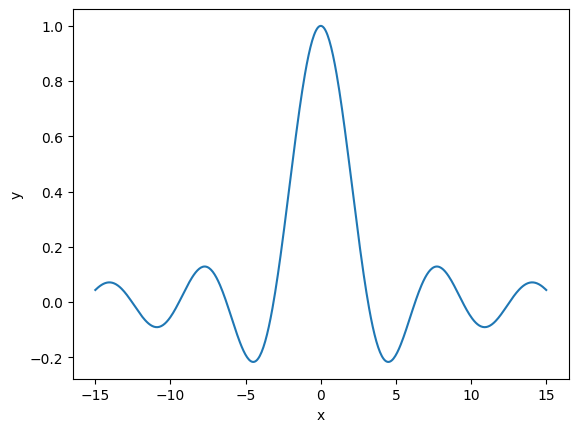

In [3]:
# 1. Create data for interpolation (approximate a function) and data loaders
def create_dataloaders(x, y, train_ratio=0.8, batch_size=32, shuffle=True):
    """Create train and validation dataloaders"""
    dataset = TensorDataset(x, y)
    
    # Split
    train_size = int(train_ratio * len(dataset))
    val_size = len(dataset) - train_size
    train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
    
    # Create dataloaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=shuffle)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    
    return train_loader, val_loader

def extract_from_subset(subset):
    """Extract data from a Subset (from random_split)"""
    original_dataset = subset.dataset
    indices = subset.indices
    x_subset = original_dataset.tensors[0][indices]
    y_subset = original_dataset.tensors[1][indices]
    return x_subset, y_subset
    
''' sin(1/x)
def gen_x_support(min_x, max_x, num_pts):
    _num_pts = int(num_pts/2)
    log_min_x = np.log10(min_x)
    log_max_x = np.log10(max_x)
    pos_x = torch.logspace(log_min_x, log_max_x, _num_pts)
    neg_x = torch.sort(-pos_x)[0]
    return torch.cat([neg_x, pos_x]).reshape(-1, 1)
    
def fun_truth(_x):
    return torch.sin(1./_x)
    
epochs = 5000
num_hidden = 3
hidden_size = 32
batch_size = 16

min_x, max_x = 1e-5, 2
x = gen_x_support(min_x, max_x, 10000)
x_test = gen_x_support(1e-4, 3., 300) # for later
y = fun_truth(x)
#'''

''' 1/x    
def fun_truth(_x):
    return 1./_x
    
epochs = 1000
num_hidden = 2 # 3 is gooBrachiod-ish enough
hidden_size = 32
batch_size = 16

min_x, max_x = -2, 2
x = torch.linspace(min_x, max_x, 500).reshape(-1, 1)
x_test = torch.linspace(min_x*1.5, max_x*1.5, 100).reshape(-1, 1) # for later
y = fun_truth(x)
#'''

#''' sin(x)/x    
def fun_truth(_x):
    return torch.sin(_x)/_x
    
epochs = 5000
num_hidden = 4 # 3 is good-ish enough
hidden_size = 32
batch_size = 16

min_x, max_x = -15, 15
x = torch.linspace(min_x, max_x, 500).reshape(-1, 1)
x_test = torch.linspace(min_x*1.5, max_x*1.5, 100).reshape(-1, 1) # for later
y = fun_truth(x)
#'''

''' sin(x)
def fun_truth(_x, noise_amp = 0.):
    return torch.sin(x) + noise_amp * torch.randn_like(x)
    
epochs = 1000
num_hidden = 3
hidden_size = 32
batch_size = 16

min_x, max_x = -5, 5
x = torch.linspace(min_x, max_x, 500).reshape(-1, 1)
x_test = torch.linspace(min_x*1.5, max_x*1.5, 100).reshape(-1, 1) # for testing later
y = fun_truth(x)
#'''

train_loader, val_loader = create_dataloaders(x, y,
                                              batch_size=batch_size)
print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")

# Visualise thing you're trying to interpolate
plt.plot(x, y)
plt.xlabel('x')
plt.ylabel('y')

In [4]:
# 2. Define the MLP class
class MLP(nn.Module):
    def __init__(self,
                 input_size,
                 hidden_size=32,
                 output_size=1,
                 num_hidden=2):
        super().__init__()

        # Build layers dynamically
        layers = []
        
        # First hidden layer (input → hidden)
        layers.append(nn.Linear(input_size, hidden_size))
        layers.append(nn.ReLU())
        
        # Additional hidden layers (hidden → hidden)
        for _ in range(num_hidden-1):
            layers.append(nn.Linear(hidden_size, hidden_size))
            layers.append(nn.ReLU())

        # Output layer
        layers.append(nn.Linear(hidden_size, output_size))
        
        # Create sequential
        self.layers = nn.Sequential(*layers)  # * unpacks the list

        self._init_weights()

    def _init_weights(self):
        """Xavier initialization for better convergence"""
        for layer in self.layers:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)
        return None

    def forward(self, x):
        return self.layers(x)

In [5]:
# 3. Create model, loss, optimizer
model = MLP(input_size=1,
            num_hidden=num_hidden,
            hidden_size=hidden_size,
           ).to(device)

print(f"Model structure: {model}\n\n")

'''
for name, param in model.named_parameters():
    print(f"Layer: {name} | Size: {param.size()} | Values : {param[:2]} \n")
'''

Model structure: MLP(
  (layers): Sequential(
    (0): Linear(in_features=1, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=32, bias=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=32, bias=True)
    (7): ReLU()
    (8): Linear(in_features=32, out_features=1, bias=True)
  )
)




'\nfor name, param in model.named_parameters():\n    print(f"Layer: {name} | Size: {param.size()} | Values : {param[:2]} \n")\n'

In [6]:
loss_function = nn.MSELoss()  # For regression
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [7]:
# 4. Training loop
def train_epoch(model, loader, optimizer, criterion, device):
    """Train for one epoch"""
    model.train()
    total_loss = 0
    
    for batch_x, batch_y in loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        
        optimizer.zero_grad()

        # forwards
        predictions = model(batch_x)
        loss = loss_function(predictions, batch_y)

        # backwards
        loss.backward()

        # update weights
        optimizer.step()
        
        total_loss += loss.item() * batch_x.size(0)
    
    return total_loss / len(loader.dataset)

def validate(model, loader, criterion, device):
    """Validate model"""
    model.eval()
    total_loss = 0
    
    with torch.no_grad():
        for batch_x, batch_y in loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            predictions = model(batch_x)
            loss = loss_function(predictions, batch_y)
            total_loss += loss.item() * batch_x.size(0)
    
    return total_loss / len(loader.dataset)

In [8]:
for epoch in range(epochs):
    train_loss = train_epoch(model, train_loader, optimizer, loss_function, device)
    val_loss = validate(model, val_loader, loss_function, device)
    
    if (epoch + 1) % 1000 == 0:
        print(f"Epoch {epoch+1:3d}/{epochs} | "
              f"Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")

Epoch 1000/5000 | Train Loss: 0.000197 | Val Loss: 0.000131
Epoch 2000/5000 | Train Loss: 0.000308 | Val Loss: 0.000427
Epoch 3000/5000 | Train Loss: 0.000227 | Val Loss: 0.000288
Epoch 4000/5000 | Train Loss: 0.000247 | Val Loss: 0.000261
Epoch 5000/5000 | Train Loss: 0.000116 | Val Loss: 0.000124


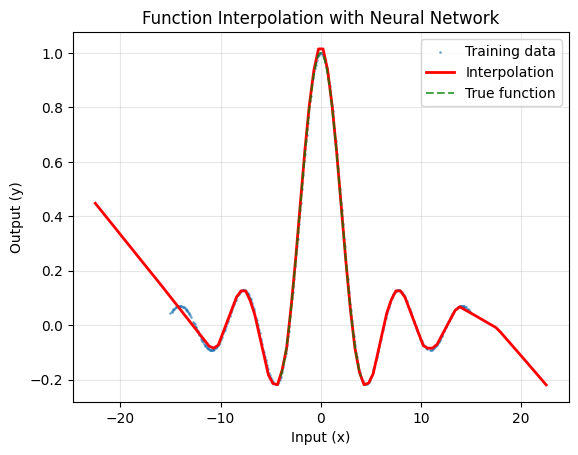

In [9]:
# 5a. Set model to evaluation mode
model.eval()

# 5b. Make predictions (no gradients needed)
with torch.no_grad():
    y_pred = model(x_test)

# 6. Visualisation
# Get training and validation data
x_train, y_train = extract_from_subset(train_loader.dataset)
x_val, y_val = extract_from_subset(val_loader.dataset)

# Training data
plt.scatter(x_train.numpy(), y_train.numpy(), 
           s=1, alpha=0.5, label='Training data')

# Model prediction
plt.plot(x_test.numpy(), y_pred.numpy(), 
        'r-', linewidth=2, label='Interpolation')

# Truth
x_true = torch.linspace(-4, 4, 500).reshape(-1, 1)
y_true = fun_truth(x_true)
plt.plot(x_true.numpy(), y_true.numpy(), 
        'g--', linewidth=1.5, alpha=0.7, label='True function')

plt.xlabel('Input (x)')
plt.ylabel('Output (y)')
plt.title('Function Interpolation with Neural Network')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()